In [11]:
import tensorflow as tf
import tensorflow_datasets as tfds

# --- 設定 ---
DATASET_NAME = 'imagenette/320px-v2' 
BATCH_SIZE = 128
IMG_SIZE = 256

# ===================================================
# 步驟 0: GPU 檢查與配置
# ===================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # 設定 GPU 記憶體動態增長
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"成功偵測到 {len(gpus)} 個 GPU，(TF 版本: {tf.__version__})")
    except RuntimeError as e:
        print(f"GPU 設定失敗: {e}")
else:
    print("未偵測到 GPU，訓練將在 CPU 上運行。")

# ===================================================
# 步驟 1: 載入資料集
# ===================================================
print(f"--- 載入與檢查資料集：{DATASET_NAME} ---")

# tfds 會自動處理下載並存放在預設的 ~/tensorflow_datasets
(ds_train, ds_validation), ds_info = tfds.load(
    DATASET_NAME,
    split=['train', 'validation'],
    as_supervised=True,
    shuffle_files=True,
    with_info=True
)

print("資料集已就緒。")
print(f"訓練集數量: {ds_info.splits['train'].num_examples:,} | 驗證集數量: {ds_info.splits['validation'].num_examples:,}")
print(f"分類類別數: {ds_info.features['label'].num_classes}")

成功偵測到 1 個 GPU，(TF 版本: 2.10.0)
--- 載入與檢查資料集：imagenette/320px-v2 ---
資料集已就緒。
訓練集數量: 9,469 | 驗證集數量: 3,925
分類類別數: 10



--- 正在統計類別分布 ---


C:\Users\wtml6\AppData\Local\Temp\ipykernel_20852\2189932730.py:32: UserWarning: Glyph 24373 (\N{CJK UNIFIED IDEOGRAPH-5F35}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_20852\2189932730.py:32: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_20852\2189932730.py:32: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_20852\2189932730.py:32: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_20852\2189932730.py:32: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_20852\2189932730.py:32: UserWarning: Glyph 20998 (\

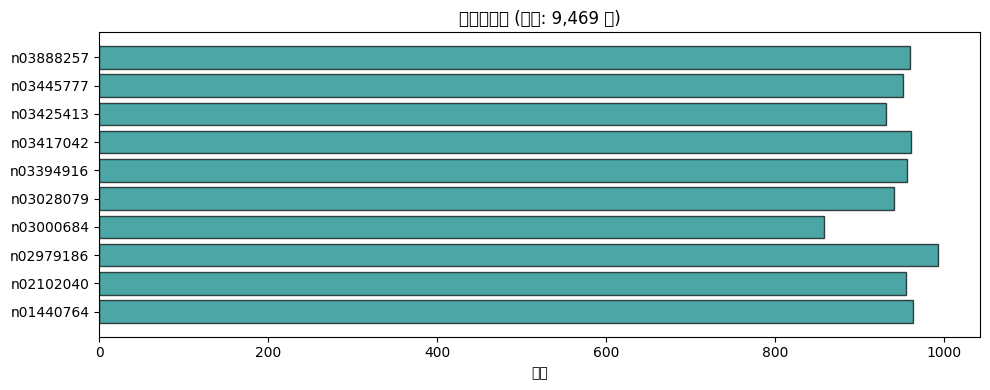


--- 隨機抽取圖片展示 ---


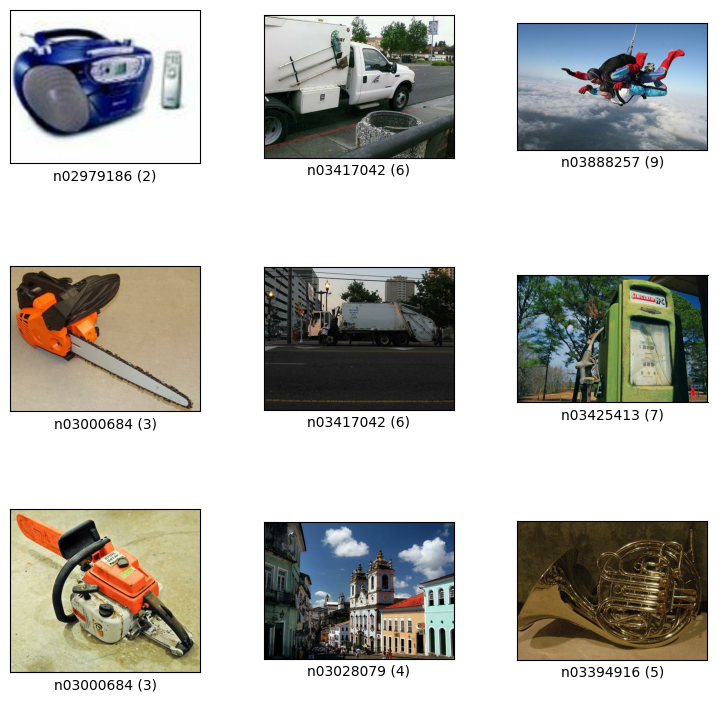


MLP 資料預處理管線已就緒！


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ===================================================
# 2.1 定義預處理與增強函數
# ===================================================
def normalize_img(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # 確保轉為浮點數並正規化至 0.0 ~ 1.0
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    return image, label

# ===================================================
# 步驟 2.2: 類別統計與展示
# ===================================================
print("\n--- 正在統計類別分布 ---")

# 為了保險，加上 .take(-1) 確保抓到所有資料，但不改變原始變數
labels_only = ds_train.map(lambda img, lbl: lbl)
all_labels_array = np.array(list(labels_only.as_numpy_iterator()))
counts = np.bincount(all_labels_array)

# 繪製長條圖
plt.figure(figsize=(10, 4))
plt.barh(class_names, counts, color='teal', alpha=0.7, edgecolor='black')
plt.title(f"訓練集分布 (總計: {counts.sum():,} 張)")
plt.xlabel("張數")
plt.tight_layout()
plt.show()

print("\n--- 隨機抽取圖片展示 ---")
# 展示時直接傳入原始 ds_train 即可
tfds.show_examples(ds_train, ds_info)
plt.show()

# ===================================================
# 2.3 準備最終的訓練/驗證管線
# ===================================================
BUFFER_SIZE = tf.data.AUTOTUNE 

ds_train_pipe = (ds_train
            .map(normalize_img, num_parallel_calls=BUFFER_SIZE)
            .cache() 
            .map(augment, num_parallel_calls=BUFFER_SIZE)
            .shuffle(buffer_size=1000) 
            .batch(BATCH_SIZE)
            .prefetch(BUFFER_SIZE))

ds_validation_pipe = (ds_validation
                 .map(normalize_img, num_parallel_calls=BUFFER_SIZE)
                 .batch(BATCH_SIZE)
                 .prefetch(BUFFER_SIZE))

print("\nMLP 資料預處理管線已就緒！")

3.1:隨機選擇要不要翻轉
因為傳統只會讓機器死背，但這樣會讓LOSS下降很多，所以翻轉圖片，讓機器學習狗的耳朵長什麼樣，鼻子在哪...讓它更加準確

In [14]:
import time

# ===================================================
# 3.1 自定義訓練日誌
# ===================================================
class FullHistoryLogger(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.train_start_time = time.time()
        print(f"🚀 訓練啟動: {time.strftime('%H:%M:%S', time.localtime())}")
        print("=" * 70)

    def on_epoch_end(self, epoch, logs=None):
        acc, val_acc = logs.get('accuracy', 0), logs.get('val_accuracy', 0)
        print(f"✨ [Epoch {epoch + 1}] Acc: {acc:.4f} | Val_Acc: {val_acc:.4f}")
        print("-" * 70)


# ===================================================
# 3.2 優化版 MLP 模型定義
# ===================================================

# 確保程式知道總共有幾個類別要分類 (Imagenette 預設為 10)
if 'ds_info' in locals():
    num_classes = ds_info.features['label'].num_classes
else:
    num_classes = 10  # 如果 ds_info 沒抓到，直接手動指定

model = tf.keras.Sequential([
    # 壓平圖片：將 [256, 256, 3] 的 3D 數據轉為 1D
    tf.keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(), 
    
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4), 
    
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"MLP 模型已就緒，目標分類類別數：{num_classes}")
model.summary()
# ===================================================
# 3.3 訓練模型
# ===================================================
EPOCHS = 15
history_logger = FullHistoryLogger()

print(f"\n--- 開始訓練 (目標: {EPOCHS} 個週期) ---")

# 餵入帶有 _pipe 的管線，5070 才能一箱一箱處理資料
history = model.fit(
    ds_train_pipe,
    epochs=EPOCHS,
    validation_data=ds_validation_pipe,
    verbose=2,                  
    callbacks=[history_logger] 
)

duration_min = (time.time() - history_logger.train_start_time) / 60
print(f"\n🎉 訓練完成！總耗時: {duration_min:.2f} 分鐘")

MLP 模型已就緒，目標分類類別數：10
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 196608)            0         
                                                                 
 dense_5 (Dense)             (None, 512)               100663808 
                                                                 
 batch_normalization_4 (Batc  (None, 512)              2048      
 hNormalization)                                                 
                                                                 
 dense_6 (Dense)             (None, 256)               131328    
                                                                 
 batch_normalization_5 (Batc  (None, 256)              1024      
 hNormalization)                                                 
                                                                 
 dropout_2 (Dropout)         (Non


--- 訓練結果分析 ---
最低驗證損失 (Min Validation Loss): 1.9792
模型達到最佳狀態的時間 (Best Epoch): 第 10 週期


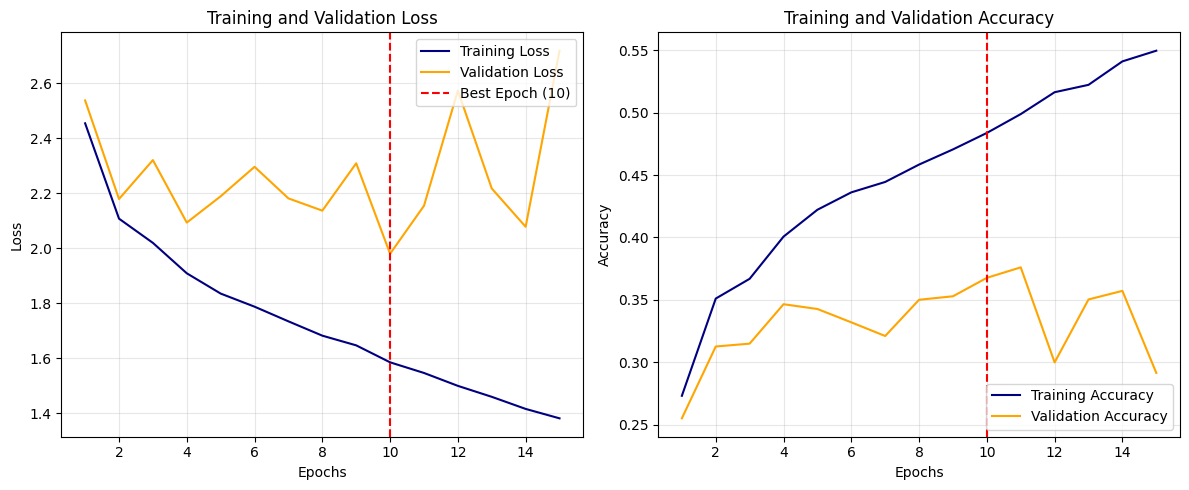

已成功產出圖表，這對於你的專題進度分析非常有幫助。


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ===================================================
# 4.1 找出最佳時間
# ===================================================
val_loss = history.history['val_loss']
min_val_loss = min(val_loss)
best_epoch = np.argmin(val_loss) + 1  # 週期從 1 開始計算

print(f"\n--- 訓練結果分析 ---")
print(f"最低驗證損失 (Min Validation Loss): {min_val_loss:.4f}")
print(f"模型達到最佳狀態的時間 (Best Epoch): 第 {best_epoch} 週期")

# ===================================================
# 4.2 繪製 Accuracy 和 Loss 曲線圖
# ===================================================
def plot_history(history, filename='training_history_mlp.png'):
    # 提取數據
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, v_loss = history.history['loss'], history.history['val_loss']
    
    # X 軸統一從 1 開始，讓標記直覺
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # --- 繪製 Loss 曲線 ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Training Loss', color='navy')
    plt.plot(epochs_range, v_loss, label='Validation Loss', color='orange')
    # 紅色虛線直接對準 best_epoch
    plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # --- 繪製 Accuracy 曲線 ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='navy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
    plt.axvline(x=best_epoch, color='red', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# 執行繪圖
plot_history(history)
print(f"已成功產出圖表，這對於你的專題進度分析非常有幫助。")